In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import pickle
import matplotlib.pyplot as plt
import numpy as np

from Modules.panel_utils import (
    detect_outlier_regions_iqr,
)
import seaborn as sns

CLUSTER_CONFIG = {
    "feature_cols": ["Salary_def", "CD_index", 'Credit_load_Mort', 'D_top5_rozn',],  #"D_top5_rozn, 'Credit_load_Mort', 'Coef_sec',  "Def_Zadolg_Fl",
    "outlier_check_cols": ["Coef_sec", "Salary_def", "CD_index", "Def_Zadolg_Fl"],
    "years": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "agg_func": "median",
    "k_range": range(2, 11),
    "n_clusters": 4,
    "reference_cluster": 2,  # Не должен быть выше n_clusters
    "random_state": 42,
    "n_init": 10,
}

In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################

df_clustering = pd.read_excel('База данных_рег и фед показатели.xlsx', sheet_name = 'data_clust')

df_clustering["Date"]   = pd.to_datetime(df_clustering["Date"], dayfirst=True, errors="coerce")
# Правильный вариант запроса
df_clustering = df_clustering.query(
    "Date < '2026-01-01'"
).reset_index(drop=True)


In [3]:
# Крым и Севастополь из-за недостатка данных 
# Республика Тыва, Республика Дагестан, Чеченская Республика из-за выбросов в данных

In [4]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = CLUSTER_CONFIG["outlier_check_cols"]
region_quality_iqr = detect_outlier_regions_iqr(df_clustering, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_clustering = df_clustering[df_clustering['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_clustering.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 81 РЕГИОНОВ (IQR)
                             Region  N_obs NA_pct  IQR_outliers IQR_pct Bad_Indicators Indicator_Problem Reasons Status
               Белгородская область     83   0.0%             0    0.0%                                            KEEP
                   Брянская область     83   0.0%             0    0.0%                                            KEEP
               Владимирская область     83   0.0%             0    0.0%                                            KEEP
                Воронежская область     83   0.0%             0    0.0%                                            KEEP
                 Ивановская область     83   0.0%             0    0.0%                                            KEEP
                   Тверская область     83   0.0%             0    0.0%                                            KEEP
                  Калужская область     83   0.0%             0    0.0%                              

In [5]:
descriptive_df = df_clustering.drop(columns=['Date', 'Region',  #'Year'
                                            ], axis = 0, inplace=False)


desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАРАМЕТРЫ КЛАСТЕРИЗАЦИИ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАРАМЕТРЫ КЛАСТЕРИЗАЦИИ
                               Среднее    Медиана  ст. откл.       Мин.  \
Coef_sec                         1.394      1.373      0.360      0.000   
CD_index                         0.747      0.554      0.783      0.108   
Unemp                            4.895      3.900      3.947      0.708   
Salary_def                   56746.543  52076.850  20092.893  25522.465   
Def_Zadolg_Fl                    4.511      4.281      1.604      2.137   
Def_Zadolg_FL_by_TrudPeople     12.274     11.936      4.473      0.782   
Cred_nagr                       34.763     35.215      9.179      5.066   
Zakred                          58.760     59.349     15.736      8.905   
LTV_proksi                       0.677      0.703      0.132      0.000   
Coef_prim                        1.555      1.645      0.681      0.000   
Credit_load_Mort                33.025     31.712      9.193     12.531   
D_top5_rozn                      0.785      0.783

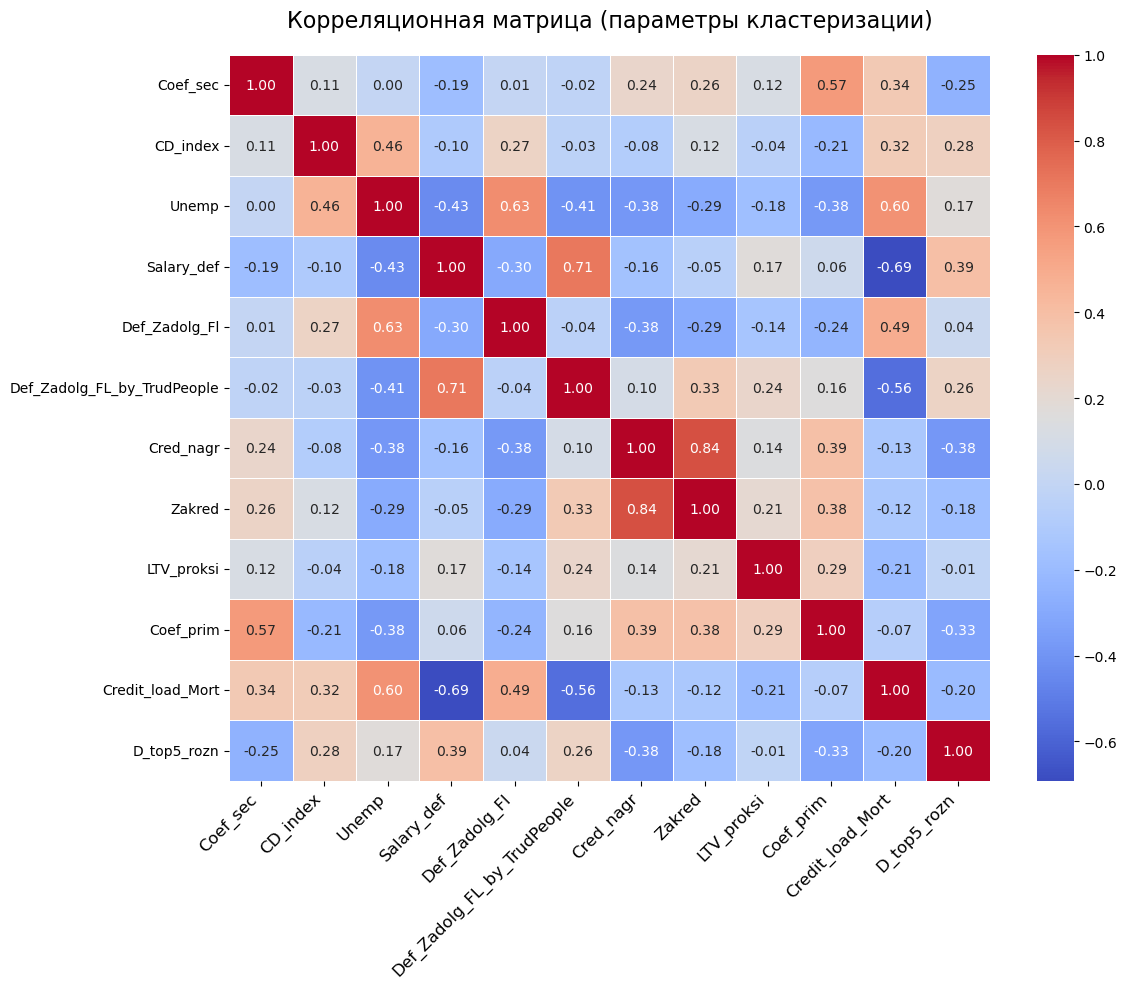

In [6]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАРАМЕТРЫ КЛАСТЕРИЗАЦИИ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (параметры кластеризации)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [7]:

cols_clustering = list(dict.fromkeys(CLUSTER_CONFIG["outlier_check_cols"] + CLUSTER_CONFIG["feature_cols"]))
for c in cols_clustering:
    df_clustering[c] = pd.to_numeric(df_clustering[c], errors="coerce")

df_clustering["Year"] = df_clustering["Date"].dt.year

In [8]:
# Выбираем за какие годы проводим кластеризацию
df_clustering_recent = df_clustering[df_clustering["Year"].isin(CLUSTER_CONFIG["years"])]

agg_map = {
    col: (col, CLUSTER_CONFIG["agg_func"])
    for col in CLUSTER_CONFIG["feature_cols"]
}

df_clustering_year = (
    df_clustering_recent
    .groupby("Region", as_index=False)
    .agg(**agg_map)
)
with open('true_filter_for_cluster.pkl', 'rb') as f:
    good_regions_iqr = pickle.load(f)

good_regions_iqr = [x for x in good_regions_iqr if x != 'Республика Ингушетия']

df_clust = df_clustering_year[df_clustering_year["Region"].isin(good_regions_iqr)].dropna().copy()

features = CLUSTER_CONFIG["feature_cols"]
X = df_clust[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
###############################
    #ПОДБОР ЧИСЛА КЛАСТЕРОВ
###############################
inertias = []
silhouette_scores = []
K_range = CLUSTER_CONFIG["k_range"]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=CLUSTER_CONFIG["random_state"], n_init=CLUSTER_CONFIG["n_init"])
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

k=2: inertia=205.79, silhouette=0.4017
k=3: inertia=145.97, silhouette=0.4354
k=4: inertia=121.86, silhouette=0.2783
k=5: inertia=102.59, silhouette=0.2528
k=6: inertia=90.50, silhouette=0.2599
k=7: inertia=84.06, silhouette=0.1995
k=8: inertia=71.25, silhouette=0.2611
k=9: inertia=65.42, silhouette=0.2479
k=10: inertia=59.11, silhouette=0.2381


Лучшее k по силуэту: 3


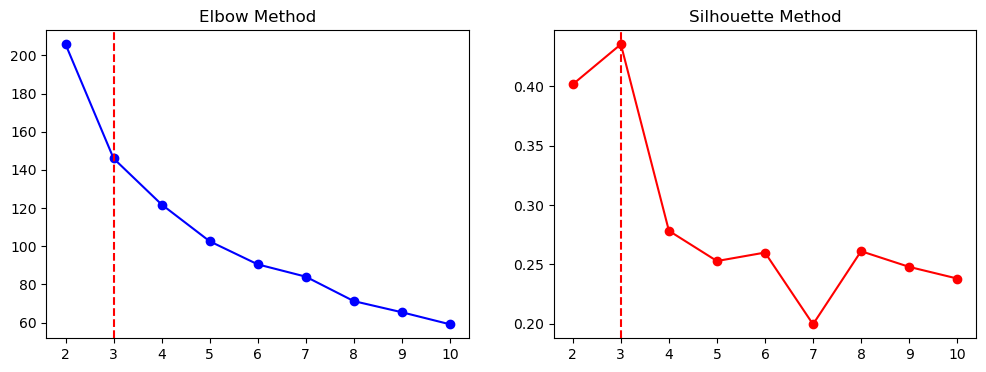

In [10]:
# Лучший k по силуэту
best_k_sil = K_range[np.argmax(silhouette_scores)]
print(f"Лучшее k по силуэту: {best_k_sil}")

# Локоть – более субъективно, но можно взять 3-4

# Графики для интерпретации
elbow_k = CLUSTER_CONFIG["n_clusters"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.axvline(best_k_sil, color='r', linestyle='--', label=f'best_k_sil={best_k_sil}')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.axvline(best_k_sil, color='r', linestyle='--')
ax2.set_title('Silhouette Method')

plt.show()


In [11]:
###############################
    #ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ
###############################

optimal_k = CLUSTER_CONFIG["n_clusters"]
kmeans = KMeans(n_clusters=optimal_k, random_state=CLUSTER_CONFIG["random_state"], n_init=CLUSTER_CONFIG["n_init"])
df_clust["Cluster"] = kmeans.fit_predict(X_scaled) + 1

In [12]:
'''#Меняем метки в датасете 
df_clust.loc[df_clust["Cluster"] == 3, "Cluster"] = -1
df_clust.loc[df_clust["Cluster"] == 4, "Cluster"] = 3
df_clust.loc[df_clust["Cluster"] == -1, "Cluster"] = 4

#Переупорядочиваем центроиды
centers_reordered = kmeans.cluster_centers_.copy()
centers_reordered[[2, 3]] = centers_reordered[[3, 2]]  

#Создаём новый kmeans с переупорядоченными центроидами 
kmeans_reordered = KMeans(n_clusters=optimal_k, init=centers_reordered, n_init=1, max_iter=300, random_state=CLUSTER_CONFIG["random_state"])
kmeans_reordered.fit(X_scaled)  # формально переобучаем, но с фиксированными начальными центрами
'''
# Регионы, наиболее близкие к цетроидам для каждого кластера
closest_regions = []

for cl in sorted(df_clust["Cluster"].unique()):
    mask = df_clust["Cluster"] == cl
    points = X_scaled[mask]
    center = kmeans.cluster_centers_[cl - 1]  
#kmeans_reordered
    dists = np.linalg.norm(points - center, axis=1)
    idx_min = dists.argmin()
    
    row_closest = df_clust[mask].iloc[idx_min]
    closest_regions.append(row_closest)

closest_df = pd.DataFrame(closest_regions)
print(closest_df[["Cluster", "Region", *CLUSTER_CONFIG["feature_cols"]]])


    Cluster                           Region    Salary_def  CD_index  \
55        1             Республика Татарстан  58846.497836  0.529031   
51        2              Республика Марий Эл  45497.244584  0.580976   
17        3                  Камчатский край  69194.882151  0.478242   
18        4  Карачаево-Черкесская Республика  38575.636632  1.330182   

    Credit_load_Mort  D_top5_rozn  
55         32.740194     0.711300  
51         30.792096     0.772255  
17         21.374416     0.860327  
18         47.156309     0.822174  


In [13]:
summary_agg = {col: ["mean", "median"] for col in CLUSTER_CONFIG["feature_cols"]}
cluster_summary_new = df_clust.groupby("Cluster").agg(summary_agg).round(2).reset_index()


print("Характеристики кластеров:")
print(cluster_summary_new.to_string(index=False))

Характеристики кластеров:
Cluster Salary_def          CD_index        Credit_load_Mort        D_top5_rozn       
              mean   median     mean median             mean median        mean median
      1   56183.13 54325.34     0.55   0.52            32.22  32.64        0.71   0.71
      2   47969.13 47542.72     0.55   0.52            31.80  31.63        0.77   0.77
      3   73879.52 70845.98     0.63   0.62            22.79  23.45        0.85   0.84
      4   40163.36 40041.43     1.37   1.36            44.50  47.38        0.82   0.81


In [14]:
# Список регионов по кластерам
hank_clusters_regions = (
    df_clust
    .sort_values(["Cluster", "Region"])
    .groupby("Cluster")["Region"]
    .apply(list)
    .reset_index(name="Regions")
)

print("=== КЛАСТЕРЫ ===")
for _, row in hank_clusters_regions.iterrows():
    cluster_id = row["Cluster"]
    regions = row["Regions"]
    n_regions = len(regions)
    
    print(f"\n Кластер {cluster_id} ({n_regions} регионов):")
    for r in sorted(regions):  # алфавитный порядок
        print(f"  {r}")
    print("-" * 50)


=== КЛАСТЕРЫ ===

 Кластер 1 (16 регионов):
  Волгоградская область
  Калининградская область
  Краснодарский край
  Ленинградская область
  Московская область
  Нижегородская область
  Новосибирская область
  Республика Адыгея
  Республика Башкортостан
  Республика Татарстан
  Самарская область
  Свердловская область
  Томская область
  Челябинская область
  г. Москва
  г. Санкт-Петербург
--------------------------------------------------

 Кластер 2 (44 регионов):
  Алтайский край
  Архангельская область
  Астраханская область
  Белгородская область
  Брянская область
  Владимирская область
  Вологодская область
  Воронежская область
  Еврейская автономная область
  Ивановская область
  Кабардино-Балкарская Республика
  Калужская область
  Кемеровская область
  Кировская область
  Костромская область
  Курганская область
  Курская область
  Липецкая область
  Новгородская область
  Омская область
  Оренбургская область
  Орловская область
  Пензенская область
  Пермский край
  Примор

In [15]:
region_cluster = df_clust[['Region', 'Cluster']].copy()
region_cluster.head()

,Region,Cluster
0,Алтайский край,2
1,Амурская область,3
2,Архангельская область,2
3,Астраханская область,2
4,Белгородская область,2


In [16]:
#region_cluster.to_excel('region_cluster.xlsx')

In [17]:
### Фильтруем Адыгею

region_cluster = region_cluster[region_cluster['Region'] != 'Республика Адыгея']

In [18]:
cluster_dummies = pd.get_dummies(region_cluster['Cluster'],prefix='Cluster_new_cd').astype(int)

region_cluster = pd.concat([region_cluster, cluster_dummies], axis=1)

reference_cluster_col = f"Cluster_new_cd_{CLUSTER_CONFIG['reference_cluster']}"
region_cluster = region_cluster.drop(columns=['Cluster', reference_cluster_col], errors='ignore')

region_cluster.head()

,Region,Cluster_new_cd_1,Cluster_new_cd_3,Cluster_new_cd_4
0,Алтайский край,0,0,0
1,Амурская область,0,1,0
2,Архангельская область,0,0,0
3,Астраханская область,0,0,0
4,Белгородская область,0,0,0


In [19]:
pickle_filename = 'region_cluster_final.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(region_cluster, f)

In [20]:
###############################
# ЭКСПОРТ КЛАСТЕРОВ В EXCEL
###############################

# --- Лист 1: Характеристики кластеров ---
chars_export = cluster_summary_new.copy()
chars_export.columns = [
    col[0] if col[1] == '' else f"{col[0]}_{col[1]}"
    for col in chars_export.columns
]

# --- Лист 2: Состав кластеров ---
cluster_ids = sorted(df_clust["Cluster"].unique())
cluster_regions = {
    f"Кластер {cl}": sorted(df_clust[df_clust["Cluster"] == cl]["Region"].tolist())
    for cl in cluster_ids
}
max_len = max(len(v) for v in cluster_regions.values())
clusters_df = pd.DataFrame({
    k: v + [None] * (max_len - len(v))
    for k, v in cluster_regions.items()
})

# --- Запись в Excel ---
output_path = "clusters_export.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    chars_export.to_excel(writer, sheet_name="Характеристики", index=False)
    clusters_df.to_excel(writer, sheet_name="Кластеры", index=False)

print(f"Файл сохранён: {output_path}")

Файл сохранён: clusters_export.xlsx
